In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "raw" / "sales_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,order_id,customer_id,product_id,product_name,category,city,order_date,quantity,unit_price,total_amount
0,1001,C001,P001,Laptop,Electronics,Pune,2024-01-05,1,55000,55000
1,1002,C002,P002,Mobile Phone,Electronics,Mumbai,2024-01-08,2,25000,50000
2,1003,C003,P003,Headphones,Electronics,Nashik,2024-01-15,3,1500,4500
3,1004,C004,P004,Running Shoes,Sports,Pune,2024-01-20,2,3000,6000
4,1005,C005,P005,Cricket Bat,Sports,Mumbai,2024-01-25,1,4500,4500


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   order_id      36 non-null     int64
 1   customer_id   36 non-null     str  
 2   product_id    36 non-null     str  
 3   product_name  36 non-null     str  
 4   category      36 non-null     str  
 5   city          36 non-null     str  
 6   order_date    36 non-null     str  
 7   quantity      36 non-null     int64
 8   unit_price    36 non-null     int64
 9   total_amount  36 non-null     int64
dtypes: int64(4), str(6)
memory usage: 2.9 KB


In [3]:
df.describe()

,order_id,quantity,unit_price,total_amount
count,36.000000,36.000000,36.000000,36.000000
mean,1018.500000,1.861111,9356.944444,11725.000000
std,10.535654,0.899294,13708.241279,14680.820822
min,1001.000000,1.000000,650.000000,1600.000000
25%,1009.750000,1.000000,1425.000000,3150.000000
50%,1018.500000,2.000000,3250.000000,4750.000000
75%,1027.250000,2.000000,9750.000000,12750.000000
max,1036.000000,4.000000,55000.000000,55000.000000


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 36
Columns: 10


In [5]:
df.isnull().sum()

order_id        0
customer_id     0
product_id      0
product_name    0
category        0
city            0
order_date      0
quantity        0
unit_price      0
total_amount    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.groupby("category")["total_amount"].sum()

category
Books           13200
Clothing        28700
Electronics    236100
Furniture      114500
Sports          29600
Name: total_amount, dtype: int64

In [8]:
df.groupby("city")["total_amount"].sum()

city
Mumbai    116700
Nashik    116200
Pune      189200
Name: total_amount, dtype: int64

In [9]:
df.groupby("product_name")["total_amount"].sum().sort_values(ascending=False).head(5)

product_name
Laptop          110000
Mobile Phone     50000
Monitor          36000
Bed              30000
Sofa             25000
Name: total_amount, dtype: int64

In [10]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [11]:
df["month"] = df["order_date"].dt.to_period("M")
df.groupby("month")["total_amount"].sum()

month
2024-01    120000
2024-02     32900
2024-03     35500
2024-04     45900
2024-05     42000
2024-06     58200
2024-07     61000
2024-08     11100
2024-09      3500
2024-10     12000
Freq: M, Name: total_amount, dtype: int64

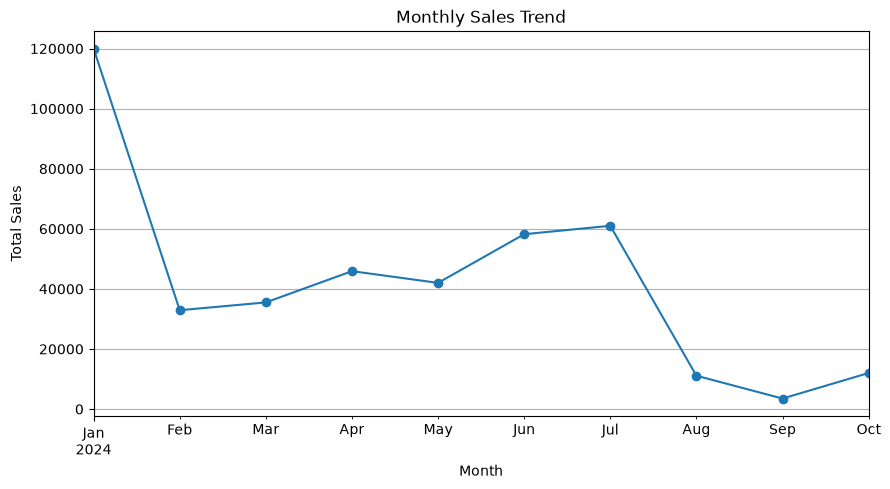

In [12]:
monthly_sales = df.groupby("month")["total_amount"].sum()

monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

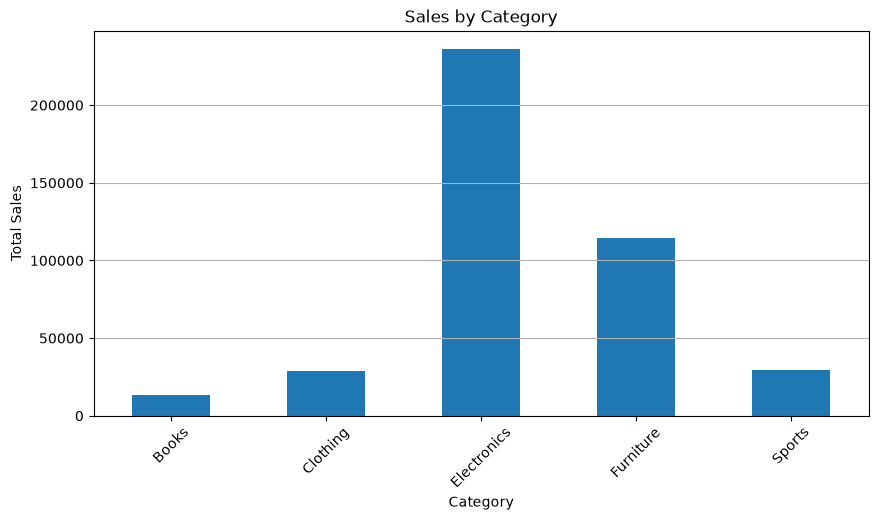

In [13]:
category_sales = df.groupby("category")["total_amount"].sum()

category_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Sales by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

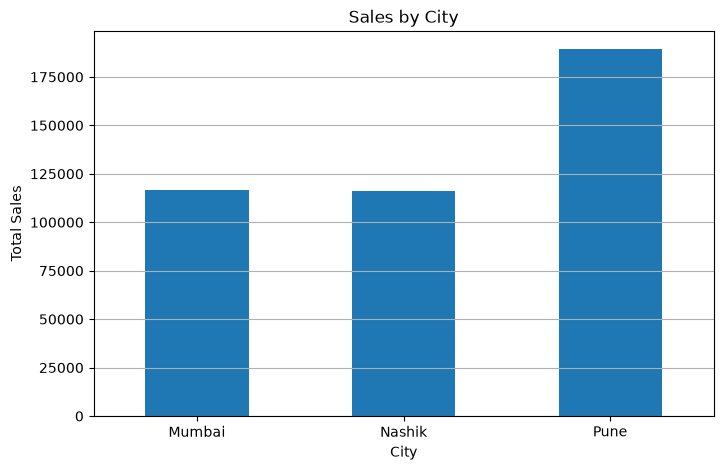

In [14]:
city_sales = df.groupby("city")["total_amount"].sum()

city_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales by City"
)

plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [15]:
total_sales = df["total_amount"].sum()
average_sales = df["total_amount"].mean()
total_orders = df["order_id"].nunique()

print("Total Sales:", total_sales)
print("Average Order Value:", round(average_sales, 2))
print("Total Orders:", total_orders)

Total Sales: 422100
Average Order Value: 11725.0
Total Orders: 36


In [16]:
output_path = BASE_DIR / "data" / "processed" / "exploration_data.csv"

df.to_csv(output_path, index=False)

print("Data exported successfully.")
print(output_path)

Data exported successfully.
c:\Users\Radhika\OneDrive\Documents\Arena internship\week7-sales-analysis\data\processed\exploration_data.csv
